# Simple Neural Networks: Building from First Principles

## Introduction

Welcome! In this notebook, we'll demystify **Artificial Neural Networks** by building them up from basic mathematical principles. You'll see that neural networks, despite their impressive capabilities, are fundamentally just **mathematical functions** that transform inputs into outputs.

## Learning Objectives

By the end of this notebook, you will understand:
- What neural networks are **mathematically** (not just conceptually)
- The key components: **weights**, **biases**, **activations**, and **activation functions**
- How to build networks from single neurons to multiple layers
- The role of **activation functions** (like $\tanh$) and why they matter
- How linear algebra (**vectors** and **matrices**) makes neural networks efficient

## From Diagrams to Mathematics

You've probably seen diagrams like this:

```
Input → ● → ● → Output
        neurons
```

**Key Insight**: Behind these pretty diagrams is just math - specifically:
- **Inputs and outputs** are numbers (or vectors of numbers)
- **Connections** are multiplication by weights
- **Neurons** apply simple mathematical operations

Let's build this understanding step by step!

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set up plotting parameters
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")
print("Ready to explore neural networks!")

Libraries imported successfully!
Ready to explore neural networks!


## Part 1: The Simplest Neural Network

### One Input, One Output

Let's start with the **absolute simplest case**: a network that takes **one number** ($a_0$) as input and produces **one number** ($a_1$) as output.

### The Mathematical Formula

$$a_1 = \sigma(w \cdot a_0 + b)$$

Let's break down each component:

| Symbol | Name | What it does |
|--------|------|--------------|
| $a_0$ | **Input Activity** | The input value |
| $a_1$ | **Output Activity** | The output value |
| $w$ | **Weight** | Scales the input (how important is it?) |
| $b$ | **Bias** | Shifts the result (baseline adjustment) |
| $\sigma$ | **Activation Function** | Adds non-linearity (more on this soon!) |

### Why "Activities"?
The term comes from neuroscience - neurons have different levels of "activity" (firing rates). In artificial neural networks, activities are just the values flowing through the network.

### The Activation Function: $\sigma$

#### Why the Strange Symbol?
The **activation function** $\sigma$ is named after the biological process in neurons:
- Real neurons receive **stimulation** from neighbors
- When stimulation exceeds a **threshold**, the neuron **activates** (fires)
- This creates a **non-linear** response

#### The Hyperbolic Tangent: $\tanh$

One common activation function is $\tanh$ (hyperbolic tangent):

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Properties of $\tanh$:
- **Range**: $[-1, 1]$ (output is always between -1 and 1)
- **S-shaped curve** (sigmoid family)
- **Smooth** and differentiable everywhere
- **Zero-centered** (unlike some other activation functions)

#### Why Do We Need Non-linearity?
Without $\sigma$, our network would just be: $a_1 = w \cdot a_0 + b$

This is a **straight line**! No matter how many layers you stack, you'd only ever get linear functions. **Non-linear activation functions** allow neural networks to learn complex patterns!

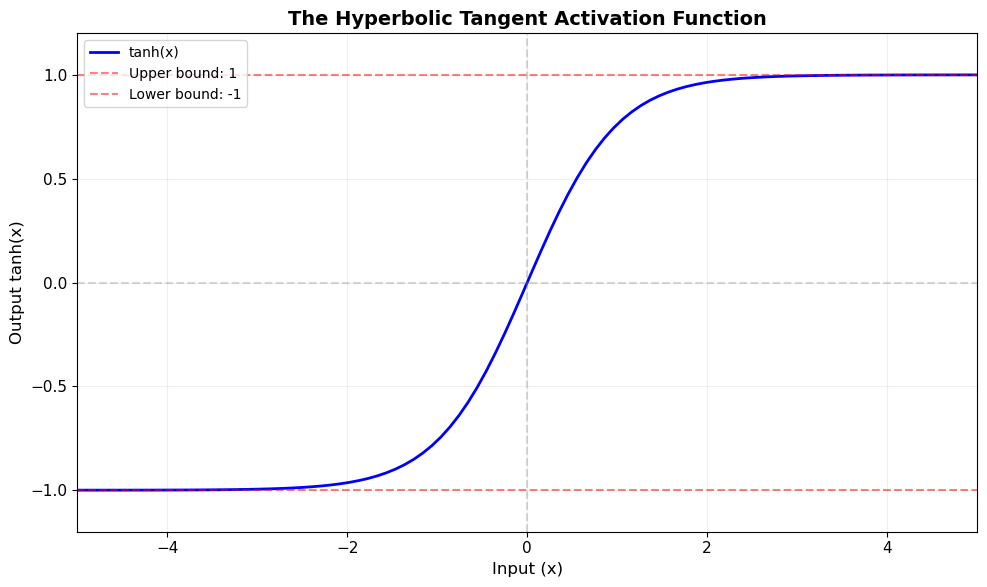

Notice the S-shape: smooth transition from -1 to 1
This non-linearity is what makes neural networks powerful!


In [2]:
# Visualize the tanh activation function
x = np.linspace(-5, 5, 100)
y = np.tanh(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='tanh(x)')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Upper bound: 1')
plt.axhline(y=-1, color='red', linestyle='--', alpha=0.5, label='Lower bound: -1')

plt.xlabel('Input (x)', fontsize=12)
plt.ylabel('Output tanh(x)', fontsize=12)
plt.title('The Hyperbolic Tangent Activation Function', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.2)
plt.legend(fontsize=10)
plt.xlim(-5, 5)
plt.ylim(-1.2, 1.2)
plt.tight_layout()
plt.show()

print("Notice the S-shape: smooth transition from -1 to 1")
print("This non-linearity is what makes neural networks powerful!")

### Building Our First Neuron

Let's implement the formula: $a_1 = \tanh(w \cdot a_0 + b)$

We'll explore how **weight** $w$ and **bias** $b$ affect the neuron's behavior.

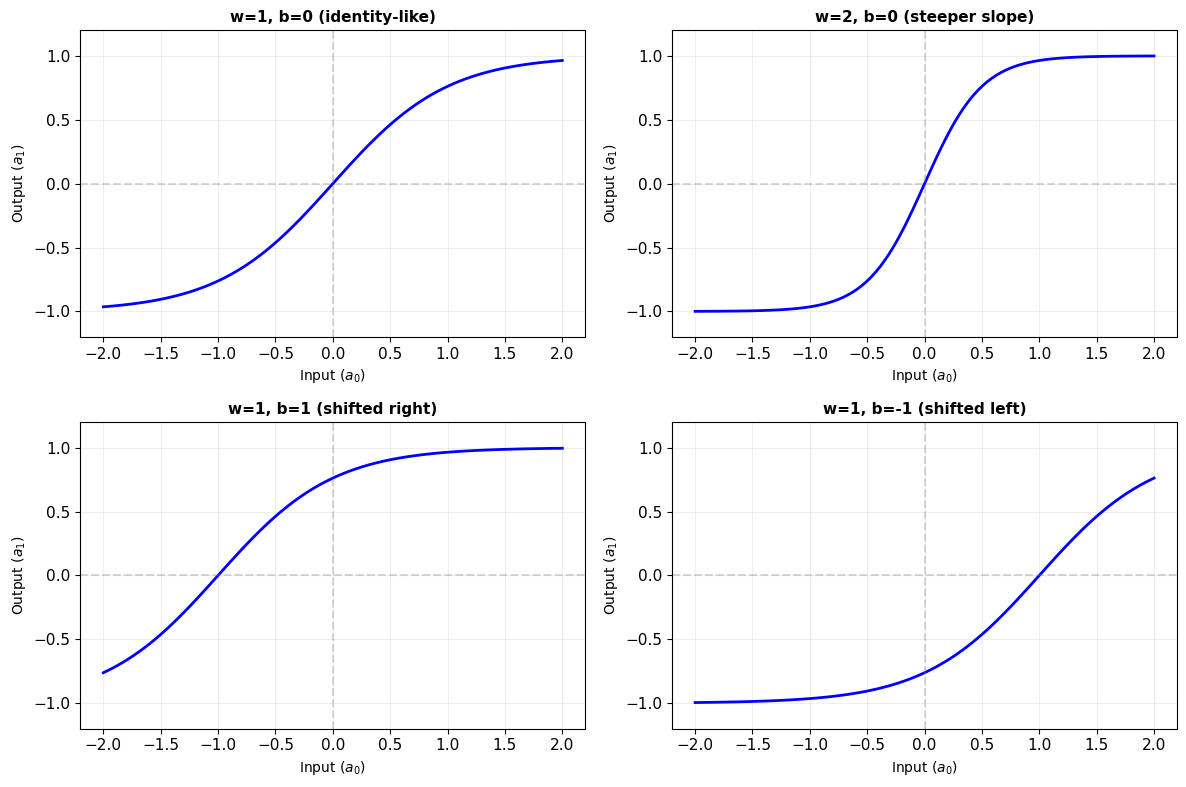

Key observations:
• Weight (w) controls the steepness of the curve
• Bias (b) shifts the curve left or right
• Output is always bounded between -1 and 1


In [3]:
# Define a simple neuron
def simple_neuron(a0, w, b):
    """
    Compute the output of a single neuron.
    
    Parameters:
    - a0: input (scalar)
    - w: weight (scalar)
    - b: bias (scalar)
    
    Returns:
    - a1: output (scalar)
    """
    return np.tanh(w * a0 + b)

# Test with different parameters
a0_values = np.linspace(-2, 2, 100)

# Different configurations
configs = [
    (1.0, 0.0, 'w=1, b=0 (identity-like)'),
    (2.0, 0.0, 'w=2, b=0 (steeper slope)'),
    (1.0, 1.0, 'w=1, b=1 (shifted right)'),
    (1.0, -1.0, 'w=1, b=-1 (shifted left)'),
]

plt.figure(figsize=(12, 8))
for i, (w, b, label) in enumerate(configs, 1):
    plt.subplot(2, 2, i)
    a1_values = [simple_neuron(a0, w, b) for a0 in a0_values]
    plt.plot(a0_values, a1_values, 'b-', linewidth=2)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    plt.xlabel('Input ($a_0$)', fontsize=10)
    plt.ylabel('Output ($a_1$)', fontsize=10)
    plt.title(label, fontsize=11, fontweight='bold')
    plt.grid(True, alpha=0.2)
    plt.ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

print("Key observations:")
print("• Weight (w) controls the steepness of the curve")
print("• Bias (b) shifts the curve left or right")
print("• Output is always bounded between -1 and 1")

## Part 2: Multiple Inputs

### Scaling Up: From One Input to Many

Now let's extend our neuron to handle **multiple inputs**. Instead of just $a_0$, we have $a_0^{(0)}, a_0^{(1)}, a_0^{(2)}, \ldots, a_0^{(n-1)}$

Each input gets its **own weight**:

$$a_1 = \sigma\left(w_0 \cdot a_0^{(0)} + w_1 \cdot a_0^{(1)} + w_2 \cdot a_0^{(2)} + \ldots + w_{n-1} \cdot a_0^{(n-1)} + b\right)$$

This is a **weighted sum** followed by the activation function.

### Vector Notation

We can write this more compactly using **vector dot product**:

$$a_1 = \sigma(\mathbf{w} \cdot \mathbf{a}_0 + b)$$

Where:
- $\mathbf{a}_0 = [a_0^{(0)}, a_0^{(1)}, \ldots, a_0^{(n-1)}]$ is the **input vector**
- $\mathbf{w} = [w_0, w_1, \ldots, w_{n-1}]$ is the **weight vector**
- $b$ is the **bias** (still a scalar)

In [4]:
# Define a multi-input neuron
def multi_input_neuron(a0_vec, w_vec, b):
    """
    Compute the output of a neuron with multiple inputs.
    
    Parameters:
    - a0_vec: input vector (numpy array)
    - w_vec: weight vector (numpy array, same shape as a0_vec)
    - b: bias (scalar)
    
    Returns:
    - a1: output (scalar)
    """
    return np.tanh(np.dot(w_vec, a0_vec) + b)

# Example: 3 inputs
a0 = np.array([0.5, -0.3, 0.8])
w = np.array([1.2, -0.5, 0.9])
b = 0.2

a1 = multi_input_neuron(a0, w, b)

print("Input vector a0:", a0)
print("Weight vector w:", w)
print("Bias b:", b)
print()
print("Computation steps:")
print(f"  1. Weighted sum: w·a0 = {w[0]}×{a0[0]} + {w[1]}×{a0[1]} + {w[2]}×{a0[2]}")
print(f"                      = {np.dot(w, a0):.4f}")
print(f"  2. Add bias: w·a0 + b = {np.dot(w, a0):.4f} + {b} = {np.dot(w, a0) + b:.4f}")
print(f"  3. Apply tanh: a1 = tanh({np.dot(w, a0) + b:.4f}) = {a1:.4f}")
print()
print(f"Final output: a1 = {a1:.4f}")

Input vector a0: [ 0.5 -0.3  0.8]
Weight vector w: [ 1.2 -0.5  0.9]
Bias b: 0.2

Computation steps:
  1. Weighted sum: w·a0 = 1.2×0.5 + -0.5×-0.3 + 0.9×0.8
                      = 1.4700
  2. Add bias: w·a0 + b = 1.4700 + 0.2 = 1.6700
  3. Apply tanh: a1 = tanh(1.6700) = 0.9316

Final output: a1 = 0.9316


## Part 3: Multiple Outputs

### Adding More Neurons

What if we want **multiple outputs**? Simple: add more neurons!

Each output neuron has its **own set of weights** and **own bias**:

$$a_1^{(0)} = \sigma(\mathbf{w}^{(0)} \cdot \mathbf{a}_0 + b^{(0)})$$
$$a_1^{(1)} = \sigma(\mathbf{w}^{(1)} \cdot \mathbf{a}_0 + b^{(1)})$$
$$a_1^{(2)} = \sigma(\mathbf{w}^{(2)} \cdot \mathbf{a}_0 + b^{(2)})$$
$$\vdots$$

### The Key Insight: Matrix Formulation

Instead of writing separate equations for each output, we can organize all the weights into a **matrix** $\mathbf{W}$:

$$\mathbf{W} = \begin{bmatrix}
w^{(0)}_0 & w^{(0)}_1 & \cdots & w^{(0)}_{n-1} \\
w^{(1)}_0 & w^{(1)}_1 & \cdots & w^{(1)}_{n-1} \\
\vdots & \vdots & \ddots & \vdots \\
w^{(m-1)}_0 & w^{(m-1)}_1 & \cdots & w^{(m-1)}_{n-1}
\end{bmatrix}$$

Where:
- Each **row** corresponds to one output neuron
- Each **column** corresponds to one input dimension
- $m$ = number of outputs, $n$ = number of inputs

The biases form a **vector** $\mathbf{b} = [b^{(0)}, b^{(1)}, \ldots, b^{(m-1)}]$

Now we can write the entire layer compactly:

$$\mathbf{a}_1 = \sigma(\mathbf{W} \mathbf{a}_0 + \mathbf{b})$$

Where $\sigma$ is applied **element-wise** to the vector $\mathbf{W} \mathbf{a}_0 + \mathbf{b}$.

In [5]:
# Define a layer with multiple outputs
def neural_layer(a0, W, b):
    """
    Compute the output of a neural network layer.
    
    Parameters:
    - a0: input vector (shape: n,)
    - W: weight matrix (shape: m × n)
    - b: bias vector (shape: m,)
    
    Returns:
    - a1: output vector (shape: m,)
    """
    return np.tanh(W @ a0 + b)

# Example: 3 inputs, 4 outputs
n_inputs = 3
n_outputs = 4

# Input
a0 = np.array([0.5, -0.3, 0.8])

# Weight matrix (4 × 3)
W = np.array([
    [ 1.2, -0.5,  0.9],  # weights for output neuron 0
    [-0.3,  0.8, -0.2],  # weights for output neuron 1
    [ 0.6,  0.4,  1.1],  # weights for output neuron 2
    [-0.9,  0.2,  0.7]   # weights for output neuron 3
])

# Bias vector
b = np.array([0.2, -0.1, 0.3, 0.0])

# Compute layer output
a1 = neural_layer(a0, W, b)

print("=" * 50)
print("NEURAL LAYER COMPUTATION")
print("=" * 50)
print()
print(f"Input shape: {a0.shape} (n = {n_inputs})")
print(f"Weight matrix shape: {W.shape} (m × n = {n_outputs} × {n_inputs})")
print(f"Bias shape: {b.shape} (m = {n_outputs})")
print(f"Output shape: {a1.shape} (m = {n_outputs})")
print()
print("Input vector a0:")
print(a0)
print()
print("Weight matrix W:")
print(W)
print()
print("Bias vector b:")
print(b)
print()
print("Computation: a1 = tanh(W @ a0 + b)")
print()
print("Step 1: W @ a0 (matrix-vector multiplication)")
z = W @ a0
print(z)
print()
print("Step 2: W @ a0 + b (add bias)")
z_with_bias = z + b
print(z_with_bias)
print()
print("Step 3: tanh(W @ a0 + b) (apply activation)")
print(a1)
print()
print("=" * 50)

NEURAL LAYER COMPUTATION

Input shape: (3,) (n = 3)
Weight matrix shape: (4, 3) (m × n = 4 × 3)
Bias shape: (4,) (m = 4)
Output shape: (4,) (m = 4)

Input vector a0:
[ 0.5 -0.3  0.8]

Weight matrix W:
[[ 1.2 -0.5  0.9]
 [-0.3  0.8 -0.2]
 [ 0.6  0.4  1.1]
 [-0.9  0.2  0.7]]

Bias vector b:
[ 0.2 -0.1  0.3  0. ]

Computation: a1 = tanh(W @ a0 + b)

Step 1: W @ a0 (matrix-vector multiplication)
[ 1.47 -0.55  1.06  0.05]

Step 2: W @ a0 + b (add bias)
[ 1.67 -0.65  1.36  0.05]

Step 3: tanh(W @ a0 + b) (apply activation)
[ 0.93155168 -0.57166997  0.87639307  0.04995837]



## Part 4: Hidden Layers - Going Deep

### Stacking Layers

The real power of neural networks comes from **chaining layers together**. The output of one layer becomes the input to the next!

#### Two-Layer Network

$$\mathbf{a}_1 = \sigma(\mathbf{W}_1 \mathbf{a}_0 + \mathbf{b}_1)$$
$$\mathbf{a}_2 = \sigma(\mathbf{W}_2 \mathbf{a}_1 + \mathbf{b}_2)$$

Where:
- $\mathbf{a}_0$ is the **input layer** (original data)
- $\mathbf{a}_1$ is the **hidden layer** (intermediate representation)
- $\mathbf{a}_2$ is the **output layer** (final prediction)

#### Why "Hidden"?

The middle layer is called "hidden" because:
- We don't directly observe it (unlike input/output)
- The network learns what features to represent there
- It's where the "magic" happens!

#### General Feed-Forward Network

For an $L$-layer network:

$$\mathbf{a}_1 = \sigma(\mathbf{W}_1 \mathbf{a}_0 + \mathbf{b}_1)$$
$$\mathbf{a}_2 = \sigma(\mathbf{W}_2 \mathbf{a}_1 + \mathbf{b}_2)$$
$$\vdots$$
$$\mathbf{a}_L = \sigma(\mathbf{W}_L \mathbf{a}_{L-1} + \mathbf{b}_L)$$

This is called **feed-forward** because information flows in one direction: input → hidden layers → output.

### Architecture Summary

| Layer Type | Symbol | Description |
|------------|--------|-------------|
| Input Layer | $\mathbf{a}_0$ | Raw input data (e.g., pixels, sensor readings) |
| Hidden Layers | $\mathbf{a}_1, \mathbf{a}_2, \ldots$ | Learned feature representations |
| Output Layer | $\mathbf{a}_L$ | Final prediction (e.g., class probabilities) |
| Weights | $\mathbf{W}_1, \mathbf{W}_2, \ldots$ | Learned during training |
| Biases | $\mathbf{b}_1, \mathbf{b}_2, \ldots$ | Learned during training |

In [6]:
# Implement a feed-forward neural network
class SimpleNeuralNetwork:
    """A simple feed-forward neural network."""
    
    def __init__(self, layer_sizes):
        """
        Initialize network architecture.
        
        Parameters:
        - layer_sizes: list of layer sizes [n_input, n_hidden1, n_hidden2, ..., n_output]
        """
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes) - 1
        
        # Initialize weights and biases randomly
        self.weights = []
        self.biases = []
        
        for i in range(self.n_layers):
            W = np.random.randn(layer_sizes[i+1], layer_sizes[i]) * 0.5
            b = np.random.randn(layer_sizes[i+1]) * 0.1
            self.weights.append(W)
            self.biases.append(b)
    
    def forward(self, a0, verbose=False):
        """
        Perform forward pass through the network.
        
        Parameters:
        - a0: input vector
        - verbose: whether to print intermediate activations
        
        Returns:
        - output of the network
        """
        activations = [a0]
        
        if verbose:
            print(f"Layer 0 (Input): shape {a0.shape}")
            print(f"  Values: {a0}")
            print()
        
        # Forward propagation
        a = a0
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = W @ a + b
            a = np.tanh(z)
            activations.append(a)
            
            if verbose:
                print(f"Layer {i+1}: shape {a.shape}")
                print(f"  W shape: {W.shape}, b shape: {b.shape}")
                print(f"  z = W @ a + b: {z}")
                print(f"  a = tanh(z): {a}")
                print()
        
        return a, activations

# Example: Build a 3-layer network (input → hidden → output)
architecture = [3, 5, 2]  # 3 inputs, 5 hidden neurons, 2 outputs

print("Creating neural network with architecture:", architecture)
print(f"  Input layer: {architecture[0]} neurons")
print(f"  Hidden layer: {architecture[1]} neurons")
print(f"  Output layer: {architecture[2]} neurons")
print()

nn = SimpleNeuralNetwork(architecture)

# Test input
x = np.array([0.5, -0.3, 0.8])

print("=" * 60)
print("FORWARD PASS")
print("=" * 60)
print()

output, activations = nn.forward(x, verbose=True)

print("=" * 60)
print(f"Final output: {output}")
print("=" * 60)

Creating neural network with architecture: [3, 5, 2]
  Input layer: 3 neurons
  Hidden layer: 5 neurons
  Output layer: 2 neurons

FORWARD PASS

Layer 0 (Input): shape (3,)
  Values: [ 0.5 -0.3  0.8]

Layer 1: shape (5,)
  W shape: (5, 3), b shape: (5,)
  z = W @ a + b: [-0.46193465 -0.68293804  0.38288678 -0.17945589  0.42546976]
  a = tanh(z): [-0.43165969 -0.59342611  0.36521184 -0.17755396  0.40152838]

Layer 2: shape (2,)
  W shape: (2, 5), b shape: (2,)
  z = W @ a + b: [0.58707089 0.55554957]
  a = tanh(z): [0.52778569 0.50466793]

Final output: [0.52778569 0.50466793]


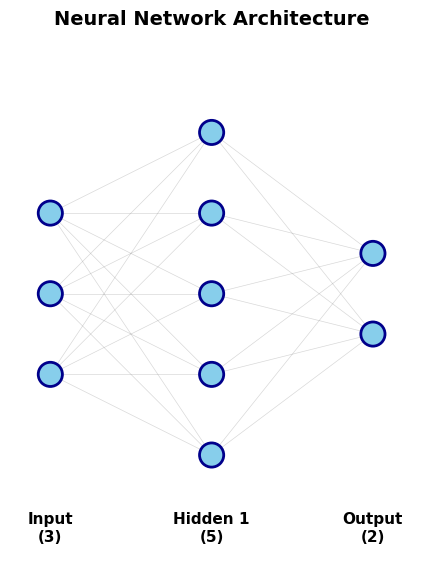

Each connection represents a weight in the weight matrices W₁ and W₂
Each neuron has an associated bias value
Total parameters: 32


In [7]:
# Visualize the network architecture
def visualize_network(layer_sizes):
    """Create a visualization of the neural network architecture."""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Layout parameters
    layer_spacing = 2.0
    max_neurons = max(layer_sizes)
    neuron_spacing = 1.0
    
    n_layers = len(layer_sizes)
    
    # Draw neurons
    neuron_positions = []
    for i, n_neurons in enumerate(layer_sizes):
        x = i * layer_spacing
        y_offset = (max_neurons - n_neurons) * neuron_spacing / 2
        
        layer_positions = []
        for j in range(n_neurons):
            y = j * neuron_spacing + y_offset
            layer_positions.append((x, y))
            
            # Draw neuron circle
            circle = plt.Circle((x, y), 0.15, color='skyblue', ec='darkblue', linewidth=2, zorder=2)
            ax.add_patch(circle)
        
        neuron_positions.append(layer_positions)
        
        # Add layer labels
        if i == 0:
            label = f"Input\n({n_neurons})"
        elif i == n_layers - 1:
            label = f"Output\n({n_neurons})"
        else:
            label = f"Hidden {i}\n({n_neurons})"
        
        ax.text(x, -0.7, label, ha='center', va='top', fontsize=11, fontweight='bold')
    
    # Draw connections
    for i in range(len(layer_sizes) - 1):
        for x1, y1 in neuron_positions[i]:
            for x2, y2 in neuron_positions[i+1]:
                ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=0.5, zorder=1)
    
    # Configure plot
    ax.set_xlim(-0.5, (n_layers - 1) * layer_spacing + 0.5)
    ax.set_ylim(-1.5, max_neurons * neuron_spacing)
    ax.axis('off')
    ax.set_aspect('equal')
    
    plt.title('Neural Network Architecture', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Visualize our network
visualize_network(architecture)

print("Each connection represents a weight in the weight matrices W₁ and W₂")
print("Each neuron has an associated bias value")
print(f"Total parameters: {sum(W.size + b.size for W, b in zip(nn.weights, nn.biases))}")

## Summary: The Building Blocks of Neural Networks

### What We've Learned

We built neural networks from the ground up, starting with the simplest case and progressively adding complexity:

1. **Single Neuron**: $a_1 = \sigma(w \cdot a_0 + b)$
   - Weight $w$ controls influence of input
   - Bias $b$ shifts the activation threshold
   - Activation function $\sigma$ introduces non-linearity

2. **Multiple Inputs**: $a_1 = \sigma(\mathbf{w} \cdot \mathbf{a}_0 + b)$
   - Weighted sum of all inputs
   - Vector dot product notation

3. **Multiple Outputs**: $\mathbf{a}_1 = \sigma(\mathbf{W} \mathbf{a}_0 + \mathbf{b})$
   - Weight matrix $\mathbf{W}$ (one row per output neuron)
   - Bias vector $\mathbf{b}$
   - Element-wise activation

4. **Deep Networks**: Chaining layers together
   - Output of layer $i$ becomes input to layer $i+1$
   - Hidden layers learn intermediate representations
   - Feed-forward architecture

### The Mathematical Beauty

Neural networks are just **compositions of simple functions**:

$$f(\mathbf{x}) = \sigma_L(\mathbf{W}_L \sigma_{L-1}(\mathbf{W}_{L-1} \cdots \sigma_1(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) \cdots + \mathbf{b}_{L-1}) + \mathbf{b}_L)$$

Despite this simplicity, they can approximate incredibly complex functions!

### Key Insights

- **Matrix formulation** makes computation efficient (using linear algebra)
- **Non-linear activations** are essential for learning complex patterns
- **Depth** (multiple layers) allows hierarchical feature learning
- Each layer transforms the input space to make patterns more separable

### What's Next?

To make these networks actually **learn**, we need:
- A **loss function** to measure prediction error
- **Backpropagation** to compute gradients
- An **optimization algorithm** (like gradient descent) to update weights

That's where the **chain rule** becomes crucial - but that's a story for another notebook! 🚀